In [18]:
from common_helper_functions import *

Filtered to 17208 common genes across all datasets.
Filtered to 17208 common genes across all datasets.
Filtered to 17208 common genes across all datasets.
Filtered to 17208 common genes across all datasets.
Filtered to 17208 common genes across all datasets.
Filtered to 17208 common genes across all datasets.


,Disease,Positives,Negatives,Total_Common_Genes,Positive_Rate
0,Mito,373,16835,17208,0.021676
1,Epilepsy,78,17130,17208,0.004533
2,Neurology,257,16951,17208,0.014935
3,Inborn Immunity,343,16865,17208,0.019933
4,Neuromuscular,123,17085,17208,0.007148
5,Ophthalmology,337,16871,17208,0.019584


<Figure size 1000x500 with 0 Axes>

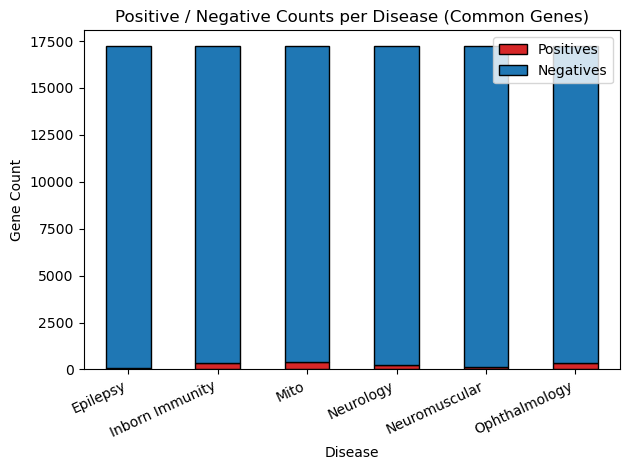

Class,Negatives,Positives
Disease,,
Epilepsy,17130,78
Inborn Immunity,16865,343
Mito,16835,373
Neurology,16951,257
Neuromuscular,17085,123
Ophthalmology,16871,337


In [19]:
embedding_datasets = {
    "Omics": omics,
    "STRING": string,
    "STRING Exp": string_exp,
    "PoPS": pops,
    "PoPS Exp": pops_exp,
    "Orthrus": orthrus
}

disease_datasets = {
    "Mito": mito,
    "Epilepsy": epilepsy,
    "Neurology": neurology,
    "Inborn Immunity": inborn_errors_immunity,
    "Neuromuscular": neuromuscular,
    "Ophthalmology": opthamology
}

def compute_disease_pos_neg_counts(embedding_datasets, disease_datasets):
    rows = []
    for disease_name, df in disease_datasets.items():
        try:
            _, target_filtered, common_genes = filter_to_common_genes(embedding_datasets, df)
            if 'target' not in target_filtered.columns:
                print(f"Skipping {disease_name}: no 'target' column.")
                continue
            pos = int(target_filtered['target'].sum())
            total = len(target_filtered)
            neg = total - pos
            rows.append({
                "Disease": disease_name,
                "Positives": pos,
                "Negatives": neg,
                "Total_Common_Genes": total,
                "Positive_Rate": pos / total if total > 0 else 0
            })
        except Exception as e:
            print(f"Error {disease_name}: {e}")
    return pd.DataFrame(rows)

def plot_disease_pos_neg(df_counts):
    plot_df = df_counts.copy()
    melted = plot_df.melt(
        id_vars=["Disease", "Total_Common_Genes", "Positive_Rate"],
        value_vars=["Positives", "Negatives"],
        var_name="Class",
        value_name="Count"
    )
    
    plt.figure(figsize=(10, 5))
    
    pivot = melted.pivot(index="Disease", columns="Class", values="Count").fillna(0)
    pivot[['Positives','Negatives']].plot(kind='bar', stacked=True, color=['#d62728','#1f77b4'], edgecolor='black')        
    plt.ylabel("Gene Count")
    plt.title("Positive / Negative Counts per Disease (Common Genes)")
    plt.xticks(rotation=25, ha='right')
    plt.legend(title="")
    plt.tight_layout()
    plt.show()
    return pivot

counts_df = compute_disease_pos_neg_counts(embedding_datasets, disease_datasets)
display(counts_df)

plot_disease_pos_neg(counts_df)

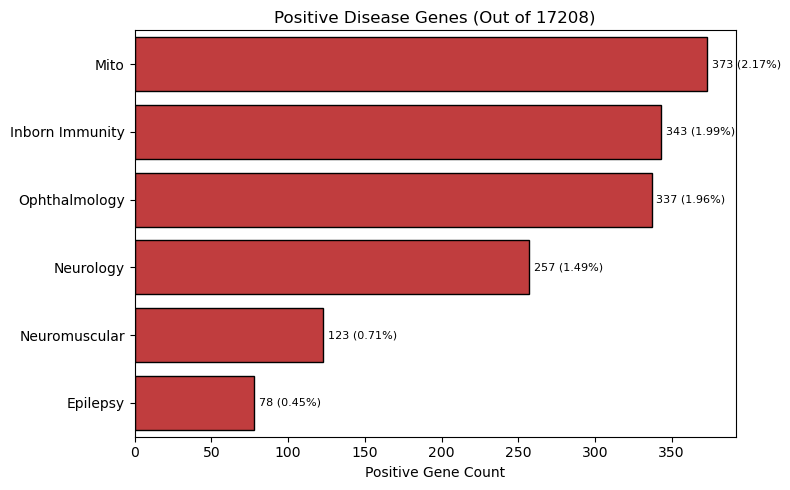

In [20]:
def plot_positive_counts_only(df_counts):
    df = df_counts.copy().sort_values('Positives', ascending=False)
    plt.figure(figsize=(8,5))
    sns.barplot(data=df, x='Positives', y='Disease', color='#d62728', edgecolor='black')
    for i, r in df.iterrows():
        plt.text(r['Positives'] + 3, df.index.get_loc(i), 
                 f"{r['Positives']} ({r['Positive_Rate']*100:.2f}%)",
                 va='center', fontsize=8)
    plt.xlabel('Positive Gene Count')
    plt.ylabel('')
    plt.title('Positive Disease Genes (Out of 17208)')
    plt.tight_layout()
    plt.show()

plot_positive_counts_only(counts_df)
